# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import random

# Import util functions
from src.modelling_utils import (
                                get_classification_metrics,
                                train_test_with_groups_and_pca, 
                                train_models_with_cv, 
                                adjust_pr_curve_from_roc,
                                get_final_feature_matrices
                                )
from src.plotting_utils import (
                                plot_precision_recall_curve, 
                                plot_roc_curve, 
                                plot_ehf_proba
                                )
from src.results_utils import (
                               get_cv_results,
                               extract_summaries_and_save,
                               get_summaries
                                )

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDOM_STATE = 4 # For reproducibility

# Introduction and Methodology

In this notebook, we are going to do model selection. 

**!!** We are going to do algorithm selection and hyperparameter selection with just one cross validation (CV). Theoretically selecting algorithm and hyperparameters with one CV is a biased method (selection bias). Correct method would be using either *Nested CV* or *3 Way Holdout + CV*. But in practice, doing one of them would not be very healthy in our circumstance:
* We have a small dataset,
* Our task is rare event detection, which means positive instances count is very low.

In these both cases, if we split our small data a lot, each splits' positive instance space would be very noisy. It would affect model and algorithm results' consistency, hence not very healthy decision making. 

So, instead we are going to use only one CV by caring consistency between interfold results. This is still manageable and practically acceptable as long as we keep these concerns in mind. 

# Data Loading and Initial Processing

In [2]:
all_feats_df = pd.read_csv("data/processed/daily_all_features.csv", index_col="datetime_local")
all_feats_df.index = pd.to_datetime(all_feats_df.index, utc=True).tz_convert("Australia/Adelaide")
all_feats_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,month_cyc_x,month_cyc_y,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean,DMT_avg30
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
daily_df = pd.read_csv("data/processed/adelaide_daily_weather_cleaned.csv", index_col="datetime_local")
daily_df.index = pd.to_datetime(daily_df.index, utc=True).tz_convert("Australia/Adelaide")

In [ ]:
# Feature groups
fg_cls= pd.read_csv('data/modelling_info/fg_cls.csv')
fg_cls

,feature_group,group_size,cumulative_pve,to_be_used_pcs
0,"['precipitation_sum7', 'precipitation_std7']",2,"[0.9635903670948435, 1.0]",1
1,"['precipitation_sum3', 'precipitation_std3']",2,"[0.9519504301550225, 0.9999999999999999]",1
2,"['wind_speed_10m_lag2', 'wind_speed_10m_avg3']",2,"[0.9269007706676774, 0.9999999999999999]",1
3,"['EHI_accl_lag3', 'EHI_accl_lag4']",2,"[0.9302000255077699, 1.0]",1
4,"['DMT_std3', 'tmax_std3']",2,"[0.9459727593038323, 1.0]",1
5,"['pressure_msl_lag1', 'pressure_msl_lag2', 'pr...",3,"[0.909740388413776, 0.9902699932238705, 1.0]",1
6,"['pressure_msl_lag3', 'pressure_msl_avg7']",2,"[0.8955354159430747, 0.9999999999999999]",1
7,"['DMT_std7', 'tmin_std7', 'tmax_std7', 'EHI_si...",4,"[0.871257895032853, 0.9461741317268824, 0.9979...",1
8,"['EHF_lag3', 'EHF_avg3', 'EHF_avg7']",3,"[0.9143955048675078, 0.9651845997143979, 0.999...",1
9,"['EHF_lag4', 'EHF_lag5']",2,"[0.9182199172946198, 1.0000000000000002]",1


In [5]:
# Drop columns
unusable_cols = ['DMT', 'tmin', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev', 
                               'wind_direction_compass', 'month_local']
all_feats_df.drop(columns=unusable_cols, inplace=True)

In [6]:
non_standardized_features =  ['month_cyc_x', 'month_cyc_y']
for c in all_feats_df.columns:
    if c.startswith('wind_unit') and 'avg' in c:
        non_standardized_features.append(c)

In [ ]:
# Dataframe it has linear and nonlinear feature filters. Created at notebook ``07_feature_selection.ipynb``.
rank_df = pd.read_csv("data/modelling_info/feature_rank_df.csv")

In [ ]:
only_linear_features = rank_df.loc[rank_df['linear_feat'] & ~rank_df['nonlinear_feat'], :].sort_values('logreg_rank', ascending=False).drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at only nonlinear models

only_nonlinear_features = rank_df.loc[rank_df['nonlinear_feat'] & ~rank_df['linear_feat'], :].sort_values('gradboost_rank', ascending=False).drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at only linear models

not_used_both = rank_df.loc[~rank_df['nonlinear_feat'] & ~rank_df['linear_feat'], :].sort_values('avg_rank').drop(columns=['linear_feat', 'nonlinear_feat'])
# Don't use at both type of models

In [ ]:
not_to_be_used_at_linear = only_nonlinear_features['feature'].to_list() + not_used_both['feature'].to_list()
not_to_be_used_at_nonlinear = only_linear_features['feature'].to_list() + not_used_both['feature'].to_list()

We are going to be passsing all features dataframe with associated `not_to_be_used` feature lists during training and evaluation processes.

In [ ]:
all_feats_df.dropna(inplace=True)
y = all_feats_df['heat_wave']
X = all_feats_df.drop(columns=['severity', 'heat_wave'])

# Main train and test sets.
X_train = X.loc[:'2020']
y_train = y.loc[:'2020']
X_test = X.loc['2021':'2024']
y_test = y.loc['2021':'2024']

# Parameter Grids and Training

We are going to train our models with following parameter grids.

In [ ]:
logreg_param_grid = [
    {'name': 'LogReg',
     'model': LogisticRegression,
     'type': 'linear',
     'params': {
        'penalty': ['l1'],
        'solver': ['liblinear'],
        'C': [0.1, 1, 25, 50, 100],
        'random_state': [RANDOM_STATE]
        }
    }
]
adaboost_param_grid = [
    {'name': 'AdaBoost',
     'model': AdaBoostClassifier,
     'type': 'nonlinear',
     'params': {
        'estimator': [DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE), 
                      DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), 
                      DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), 
                      DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)],
        'n_estimators': [50, 75, 100, 125],
        'learning_rate': [0.1, 0.2, 0.3],
        'random_state': [RANDOM_STATE]
        }
    }
]
gradboost_param_grid = [
    {'name': 'Gradient Boosting',
     'model': GradientBoostingClassifier,
     'type': 'nonlinear',
     'params': {
        'max_depth': [2, 3, 4, 5],
        'n_estimators': [50, 75, 100, 125],
        'learning_rate': [0.1, 0.2, 0.3],
        'random_state': [RANDOM_STATE]
        }
    }
]
svc_param_grid = [
    {'name': 'SVC_linear',
     'model': SVC,
     'type': 'linear',
     'params': {
        'kernel': ['linear'],
        'C': [0.05, 0.1, 1, 10, 25, 50, 100],
        'random_state': [RANDOM_STATE]
        }
    },
    {'name': 'SVC_rbf',
     'model': SVC,
     'type': 'nonlinear',
     'params': {
        'kernel': ['rbf'],
        'C': [0.05, 0.1, 1, 10, 25, 50, 100],
        'gamma': [0.01, 0.1, 1, 10, 100, 'auto'],
        'random_state': [RANDOM_STATE]
        }
    },
    {'name': 'SVC_poly',
     'model': SVC,
     'type': 'nonlinear',
     'params': {
        'kernel': ['poly'],
        'C': [0.05, 0.1, 1, 10, 25, 50, 100],
        'gamma': [0.01, 0.1, 1, 10, 100, 'auto'],
        'degree': [2, 3, 4],
        'random_state': [RANDOM_STATE]
        }
    }
]
xgb_param_grid = [
    {'name': 'XGBoost',
     'model': XGBClassifier,
     'type': 'nonlinear',
     'params': {
        'n_estimators': [2000], # We let model and data to decide best number, by using 'early_stopping_rounds' parameter.
        'early_stopping_rounds': [5],
        'max_depth': [2, 3, 4, 5],
        'eta': [0.025, 0.05, 0.075, 0.1, 0.125],
        'gamma': [0, 0.1, 0.5, 0.75, 1],
        'lambda': [0.1, 0.5, 0.75, 1],
        'scale_pos_weight': [True, False],
        # For reproducibility
        'seed': [RANDOM_STATE],
        'colsample_bytree': [1], 
        'colsample_bylevel': [1], 
        'nthread': [1]
        }
    }
]

As we might guess, training these whole grids with 5 fold CV is computationally expensive task for a PC. Because of that, we've trained our models on free *Google Colab*  account, and saved results on our local machine to analyze them later. Below is an example cell to train a grid example as shown above cell.

In [ ]:
# Example parameter grid training 
def train_grid_and_save_results(path_model_name, param_grid):
    # To be sure about reproducubility
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    train_models_with_cv(
        X_train=X_train,
        y_train=y_train,
        feature_groups_df=fg_cls,
        models_info_and_params=param_grid,
        non_standardized_features=non_standardized_features,
        not_to_be_used_at_linear=not_to_be_used_at_linear,
        not_to_be_used_at_nonlinear=not_to_be_used_at_nonlinear,
        cv_splits = 5,
        results_path=f"data/model_results/{path_model_name}_cv_results.csv"
)
train_grid_and_save_results('logreg', logreg_param_grid)

# CV Result Analysis and Model Selection
Here, we are going to load and analyze CV results. And then, decide which model to use as final model.

In [2]:
cv_results = get_cv_results(dir="data/model_results")

In [3]:
# cv_summaries = extract_summaries_and_save(cv_results, dir="data/model_results")
cv_summaries = get_summaries(dir="data/model_results")

## Logistic Regression

In [14]:
cv_summaries['logreg']

,params_C,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,1.0,0.8068,0.0104,0.7180,0.0597,0.7085,0.0846,0.9879,0.0016,0.9755,...,0.6146,0.0226,0.5429,0.1376,0.7874,0.0136,0.7764,0.0649,1.8853,0.4320
1,100.0,0.8180,0.0129,0.7065,0.0539,0.6972,0.0788,0.9885,0.0018,0.9720,...,0.6447,0.0354,0.5525,0.1252,0.7760,0.0082,0.7160,0.0113,14.1689,3.4961
2,25.0,0.8177,0.0127,0.7064,0.0547,0.6970,0.0797,0.9885,0.0018,0.9720,...,0.6378,0.0277,0.5525,0.1252,0.7752,0.0088,0.7160,0.0113,10.7674,3.3949
3,50.0,0.8180,0.0129,0.7062,0.0539,0.6969,0.0788,0.9885,0.0018,0.9720,...,0.6423,0.0326,0.5525,0.1252,0.7764,0.0082,0.7160,0.0113,11.3115,3.5630
4,0.1,0.7421,0.0155,0.7044,0.0637,0.6941,0.0890,0.9840,0.0011,0.9770,...,0.4933,0.0234,0.4304,0.1059,0.7832,0.0228,0.7907,0.0952,0.3377,0.0699


Almost all models are same, any of them would perform very close to each others (except `C=0.1`, performs worst among all). If we would be picky, we would want to select `C=1` model due to:
- `tr_pr_auc_mean`, `te_pr_auc_mean` gap is slightly lower than others, 
- `te_pr_auc_mean` slightly higher
- lowest `C` value, which means most generalized, simple and stable.

**Selection:** *index=0*, `C=1`.

## Ada Boost

In [25]:
cv_summaries['adaboost'].sort_values('te_pr_auc_mean', ascending=False)

,params_max_depth,params_learning_rate,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,3.0,0.2,75.0,0.9325,0.0402,0.7340,0.0747,0.7222,0.0977,0.9968,...,0.7456,0.0690,0.5242,0.1123,0.9015,0.0393,0.7834,0.0899,11.8362,3.0198
1,3.0,0.2,50.0,0.9182,0.0419,0.7330,0.0778,0.7216,0.0995,0.9960,...,0.7252,0.0729,0.5236,0.1022,0.8856,0.0469,0.7999,0.0866,8.3911,1.8720
2,3.0,0.2,125.0,0.9544,0.0375,0.7323,0.0805,0.7200,0.1033,0.9978,...,0.8064,0.0857,0.5102,0.1284,0.9283,0.0474,0.7912,0.1261,20.0084,5.1822
3,3.0,0.2,100.0,0.9443,0.0363,0.7307,0.0738,0.7186,0.0968,0.9974,...,0.7834,0.0552,0.5243,0.1003,0.9059,0.0376,0.7907,0.1213,15.7712,4.5744
4,5.0,0.3,125.0,1.0000,0.0000,0.7271,0.0632,0.7156,0.0844,1.0000,...,1.0000,0.0000,0.4925,0.1195,1.0000,0.0000,0.7851,0.0841,37.5859,8.1939
5,5.0,0.3,100.0,1.0000,0.0000,0.7250,0.0462,0.7146,0.0688,1.0000,...,1.0000,0.0000,0.5101,0.1154,1.0000,0.0000,0.7924,0.0800,29.6974,6.5932
6,3.0,0.1,125.0,0.9175,0.0387,0.7188,0.0717,0.7034,0.1017,0.9959,...,0.7080,0.0700,0.4651,0.0948,0.8965,0.0394,0.7616,0.0860,19.2315,6.0618
7,5.0,0.3,75.0,1.0000,0.0000,0.7180,0.0523,0.7050,0.0798,1.0000,...,1.0000,0.0000,0.5276,0.1173,1.0000,0.0000,0.8061,0.0814,21.6354,4.8429
8,3.0,0.1,75.0,0.8950,0.0415,0.7172,0.0687,0.7043,0.0945,0.9947,...,0.6679,0.0610,0.4545,0.0762,0.8806,0.0450,0.7749,0.0762,11.9849,3.1641
9,4.0,0.3,125.0,1.0000,0.0000,0.7162,0.0428,0.7057,0.0701,1.0000,...,1.0000,0.0000,0.4575,0.1071,1.0000,0.0000,0.7641,0.0725,30.6494,6.3772


There are models performs very good and close to each other. To make selection phase, we'll do prefiltering.

In [27]:
adaboost_filtered = cv_summaries['adaboost'].loc[(cv_summaries['adaboost']['tr_pr_auc_mean'] > 0.9) &
                                                (cv_summaries['adaboost']['te_pr_auc_mean'] > 0.65) & 
                                                (cv_summaries['adaboost']['adj_pr_auc_mean'] > 0.65), :]

We can check gaps between `tr_pr_auc_mean`, `adj_pr_auc_mean`; `tr_roc_auc_mean`, `te_roc_auc_mean` to get an idea of overfitting and finding the models less overfitted.

In [ ]:
adaboost_filtered['pr_auc_diff'] = (adaboost_filtered.loc[:, 'tr_pr_auc_mean'].to_numpy() - adaboost_filtered.loc[:, 'adj_pr_auc_mean'].to_numpy()).round(4)
adaboost_filtered['roc_auc_diff'] = (adaboost_filtered.loc[:, 'tr_roc_auc_mean'].to_numpy() - adaboost_filtered.loc[:, 'te_roc_auc_mean'].to_numpy()).round(4)

In [ ]:
adaboost_filtered.drop(columns=[c for c in adaboost_filtered.columns if ('precision' in c or 'recall' in c or 'time' in c)], 
                       inplace=True)
# To simplify

In [55]:
adaboost_filtered.sort_values('roc_auc_diff', ascending=True)

,params_max_depth,params_learning_rate,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,te_roc_auc_std,pr_auc_diff,roc_auc_diff
1,3.0,0.2,50.0,0.9182,0.0419,0.7330,0.0778,0.7216,0.0995,0.9960,0.0021,0.9802,0.0063,0.1966,0.0158
0,3.0,0.2,75.0,0.9325,0.0402,0.7340,0.0747,0.7222,0.0977,0.9968,0.0020,0.9802,0.0060,0.2103,0.0166
11,3.0,0.1,100.0,0.9081,0.0408,0.7142,0.0680,0.6988,0.0984,0.9954,0.0021,0.9786,0.0064,0.2093,0.0168
6,3.0,0.1,125.0,0.9175,0.0387,0.7188,0.0717,0.7034,0.1017,0.9959,0.0019,0.9788,0.0070,0.2141,0.0171
3,3.0,0.2,100.0,0.9443,0.0363,0.7307,0.0738,0.7186,0.0968,0.9974,0.0017,0.9800,0.0062,0.2257,0.0174
15,3.0,0.3,50.0,0.9244,0.0474,0.7069,0.0877,0.6835,0.1111,0.9963,0.0024,0.9788,0.0069,0.2409,0.0175
2,3.0,0.2,125.0,0.9544,0.0375,0.7323,0.0805,0.7200,0.1033,0.9978,0.0018,0.9802,0.0067,0.2344,0.0176
12,3.0,0.3,75.0,0.9436,0.0452,0.7115,0.0816,0.6928,0.1084,0.9973,0.0022,0.9793,0.0062,0.2508,0.0180
10,3.0,0.3,100.0,0.9653,0.0437,0.7150,0.0853,0.6983,0.1091,0.9984,0.0021,0.9793,0.0069,0.2670,0.0191
13,3.0,0.3,125.0,0.9756,0.0358,0.7112,0.0780,0.6980,0.1031,0.9988,0.0018,0.9788,0.0066,0.2776,0.0200


Here we focus on to choose most generalized, simple and stable model. `_diff` columns (at end of the dataframe) should be low as possible. We can focus on first five in this dataframe, due to it is sorted by `roc_auc_diff` column. Here we choose *index=0*, `max_depth=3`, `learning_rate=0.2`, `n_estimators=75` (*2nd row* in the dataframe) as our final model. This one has highest `te_pr_auc_mean`, `adj_pr_auc_mean`, `te_roc_auc_mean`. *index=1*'s (*1st row*) `pr_auc_diff` lower, but we want to keep a little more potential for full training data.

**Selection:** *index=0*, `max_depth=3`, `learning_rate=0.2`, `n_estimators=75`

## Gradient Boost

We've done a selection for this during feature selection phase, but we used full feature set there and CV grid is bigger in this phase. So we should do it again.

In [ ]:
#Prefiltering
gradboost_filtered = cv_summaries['gradboost'].loc[(cv_summaries['gradboost']['tr_pr_auc_mean'] > 0.9) &
                                                (cv_summaries['gradboost']['te_pr_auc_mean'] > 0.65) & 
                                                (cv_summaries['gradboost']['adj_pr_auc_mean'] > 0.65), :]

In [ ]:
gradboost_filtered

,params_learning_rate,params_max_depth,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,0.1,5.0,125.0,1.0000,0.0000,0.7253,0.0705,0.7145,0.0886,1.0000,...,1.0000,0.0000,0.5104,0.1017,1.0000,0.0000,0.7647,0.0774,39.4484,9.0029
1,0.1,4.0,125.0,1.0000,0.0000,0.7182,0.0560,0.7087,0.0782,1.0000,...,0.9950,0.0076,0.4928,0.1064,1.0000,0.0000,0.7929,0.0726,32.1459,6.9753
2,0.1,4.0,75.0,0.9993,0.0011,0.7146,0.0593,0.7060,0.0782,1.0000,...,0.9685,0.0287,0.4608,0.0997,0.9949,0.0093,0.8027,0.0872,19.5130,4.4299
3,0.1,4.0,100.0,0.9999,0.0002,0.7136,0.0578,0.7043,0.0794,1.0000,...,0.9872,0.0196,0.4730,0.1130,1.0000,0.0000,0.7789,0.0771,26.1027,5.7568
4,0.1,4.0,50.0,0.9954,0.0049,0.7116,0.0605,0.7032,0.0771,0.9998,...,0.9210,0.0294,0.4439,0.0965,0.9911,0.0104,0.7809,0.0695,13.3202,3.0817
5,0.1,5.0,100.0,1.0000,0.0000,0.6997,0.0709,0.6869,0.0978,1.0000,...,1.0000,0.0000,0.4431,0.0985,1.0000,0.0000,0.7350,0.0651,35.9273,8.2662
6,0.1,5.0,75.0,1.0000,0.0000,0.6956,0.0698,0.6831,0.0968,1.0000,...,1.0000,0.0000,0.4439,0.0923,1.0000,0.0000,0.7443,0.0516,26.8028,6.1779
7,0.1,5.0,50.0,0.9999,0.0001,0.6903,0.0677,0.6766,0.0961,1.0000,...,0.9965,0.0059,0.4372,0.1059,0.9993,0.0015,0.7243,0.0707,17.9419,4.1497
9,0.2,5.0,125.0,1.0000,0.0000,0.6880,0.0301,0.6788,0.0513,1.0000,...,1.0000,0.0000,0.4170,0.0741,1.0000,0.0000,0.6920,0.0514,39.2734,8.9873
10,0.1,2.0,125.0,0.9400,0.0322,0.6879,0.0819,0.6757,0.1069,0.9960,...,0.7499,0.0639,0.4599,0.0541,0.9447,0.0301,0.7353,0.1283,16.2274,3.8241


In [ ]:
gradboost_filtered['pr_auc_diff'] = (gradboost_filtered.loc[:, 'tr_pr_auc_mean'].to_numpy() - gradboost_filtered.loc[:, 'adj_pr_auc_mean'].to_numpy()).round(4)
gradboost_filtered['roc_auc_diff'] = (gradboost_filtered.loc[:, 'tr_roc_auc_mean'].to_numpy() - gradboost_filtered.loc[:, 'te_roc_auc_mean'].to_numpy()).round(4)
gradboost_filtered.drop(columns=[c for c in gradboost_filtered.columns if ('precision' in c or 'recall' in c or 'time' in c)], 
                       inplace=True)

In [ ]:
gradboost_filtered.sort_values('te_pr_auc_mean', ascending=False)

,params_learning_rate,params_max_depth,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,te_roc_auc_std,pr_auc_diff,roc_auc_diff
0,0.1,5.0,125.0,1.0000,0.0000,0.7253,0.0705,0.7145,0.0886,1.0000,0.0000,0.9764,0.0065,0.2855,0.0236
1,0.1,4.0,125.0,1.0000,0.0000,0.7182,0.0560,0.7087,0.0782,1.0000,0.0000,0.9736,0.0133,0.2913,0.0264
2,0.1,4.0,75.0,0.9993,0.0011,0.7146,0.0593,0.7060,0.0782,1.0000,0.0001,0.9756,0.0079,0.2933,0.0244
3,0.1,4.0,100.0,0.9999,0.0002,0.7136,0.0578,0.7043,0.0794,1.0000,0.0000,0.9756,0.0083,0.2956,0.0244
4,0.1,4.0,50.0,0.9954,0.0049,0.7116,0.0605,0.7032,0.0771,0.9998,0.0002,0.9757,0.0074,0.2922,0.0241
5,0.1,5.0,100.0,1.0000,0.0000,0.6997,0.0709,0.6869,0.0978,1.0000,0.0000,0.9755,0.0082,0.3131,0.0245
6,0.1,5.0,75.0,1.0000,0.0000,0.6956,0.0698,0.6831,0.0968,1.0000,0.0000,0.9754,0.0082,0.3169,0.0246
7,0.1,5.0,50.0,0.9999,0.0001,0.6903,0.0677,0.6766,0.0961,1.0000,0.0000,0.9755,0.0075,0.3233,0.0245
9,0.2,5.0,125.0,1.0000,0.0000,0.6880,0.0301,0.6788,0.0513,1.0000,0.0000,0.9691,0.0087,0.3212,0.0309
10,0.1,2.0,125.0,0.9400,0.0322,0.6879,0.0819,0.6757,0.1069,0.9960,0.0021,0.9736,0.0110,0.2643,0.0224


`roc_auc_diff` values almost all are same, we can't use it to decide. When we check this dataframe, we see every candidate has some slight overfitting. But generally, as complexity increases test performance increases too, although overfitting stays almost same. Thus picking relatively complex model might be better. Because of this fact we want to focus high `te_pr_auc_mean` and `adj_pr_auc_mean` models while we care about standart deviations and hyperparameters. In this case our best candidates are *index 1, 2, 3, 4*, `learning_rate=0.1, max_depth=4` models. Difference is `n_estimators` between these. We pick `n_estimators=50`, which has less estimators and same performance.

**Selection:** *index=4*, `learning_rate=0.1`, `max_depth=4`, `n_estimators=50`

## SVC Linear

In [63]:
cv_summaries['svc_linear']

,params_C,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,0.05,0.7937,0.0097,0.7201,0.0603,0.7109,0.0874,0.9852,0.0016,0.9760,...,0.5539,0.0179,0.4501,0.1122,0.8117,0.0159,0.8260,0.0933,0.4580,0.1738
1,0.10,0.7998,0.0099,0.7159,0.0549,0.7070,0.0828,0.9854,0.0015,0.9748,...,0.5902,0.0248,0.4780,0.1071,0.8104,0.0111,0.8088,0.0741,0.4804,0.0758
2,1.00,0.8130,0.0113,0.7055,0.0540,0.6959,0.0822,0.9859,0.0018,0.9717,...,0.6214,0.0405,0.5299,0.1295,0.8045,0.0224,0.7887,0.0510,0.9016,0.5483
3,10.00,0.8169,0.0125,0.7020,0.0564,0.6928,0.0852,0.9858,0.0018,0.9695,...,0.6353,0.0446,0.5160,0.1316,0.7989,0.0205,0.7311,0.0514,3.1874,1.9823
4,25.00,0.8170,0.0126,0.7007,0.0533,0.6917,0.0817,0.9858,0.0019,0.9690,...,0.6397,0.0492,0.5265,0.1092,0.7983,0.0209,0.7289,0.0515,9.1772,3.7463
5,50.00,0.8170,0.0128,0.6993,0.0529,0.6902,0.0812,0.9858,0.0019,0.9688,...,0.6403,0.0475,0.5265,0.1092,0.7996,0.0193,0.7222,0.0579,16.0962,5.7070
6,100.00,0.8165,0.0122,0.6988,0.0527,0.6897,0.0807,0.9857,0.0019,0.9686,...,0.6391,0.0510,0.5265,0.1092,0.8021,0.0156,0.7222,0.0579,36.3255,14.9469


There is almost not overfitting at any models. Standart deviations are almost same. We can basically pick the model with highest `te_pr_auc_mean` and `adj_pr_auc_mean`. 

**Selection**: *index=0*, `C=0.05`.

**!** Here we can see as `C` decreases (regularization increases), test performance increases slightly. In case of we select this algorithm, we can tune *C* hyperparameter more granularly.

## SVC Polynomial

In [64]:
cv_summaries['svc_poly']

,params_C,params_degree,params_gamma,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,1.00,2,0.01,0.8731,0.0140,0.6916,0.0494,0.6823,0.0743,0.9888,...,0.5217,0.0147,0.3687,0.0834,0.9246,0.0203,0.8662,0.0879,0.4212,0.0975
1,0.10,2,auto,0.8238,0.0126,0.6869,0.0577,0.6765,0.0816,0.9844,...,0.3984,0.0094,0.3093,0.0857,0.9413,0.0172,0.8968,0.0742,0.6693,0.3530
2,0.05,2,auto,0.7849,0.0103,0.6769,0.0578,0.6683,0.0851,0.9797,...,0.2689,0.0184,0.2384,0.0942,0.9387,0.0131,0.8967,0.1366,0.5293,0.0394
3,0.10,3,0.01,0.8414,0.0086,0.6714,0.0276,0.6592,0.0536,0.9888,...,0.3711,0.0113,0.2667,0.0969,0.9709,0.0305,0.8775,0.0924,0.5166,0.0685
4,0.05,3,0.01,0.8018,0.0074,0.6702,0.0402,0.6586,0.0666,0.9845,...,0.2595,0.0162,0.2170,0.1030,0.9709,0.0223,0.8957,0.1369,0.4329,0.0993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,10.00,4,100,1.0000,0.0000,0.5522,0.1012,0.5285,0.1245,1.0000,...,1.0000,0.0000,0.5175,0.1042,1.0000,0.0000,0.6677,0.1158,0.5467,0.1241
122,25.00,4,10,1.0000,0.0000,0.5522,0.1012,0.5285,0.1245,1.0000,...,1.0000,0.0000,0.5175,0.1042,1.0000,0.0000,0.6677,0.1158,0.8221,0.1840
123,25.00,4,100,1.0000,0.0000,0.5522,0.1012,0.5285,0.1245,1.0000,...,1.0000,0.0000,0.5175,0.1042,1.0000,0.0000,0.6677,0.1158,0.5404,0.1524
124,50.00,4,10,1.0000,0.0000,0.5522,0.1012,0.5285,0.1245,1.0000,...,1.0000,0.0000,0.5175,0.1042,1.0000,0.0000,0.6677,0.1158,0.5292,0.1526


In [68]:
(
    (cv_summaries['svc_poly'].loc[:, 'tr_roc_auc_mean'] - cv_summaries['svc_poly'].loc[:, 'te_roc_auc_mean'])
    .round(4).sort_values(ascending=True)
).rename('roc_auc_diff')

13     0.0215
5      0.0241
2      0.0309
4      0.0355
1      0.0402
        ...  
121    0.1287
122    0.1287
123    0.1287
124    0.1287
125    0.1287
Name: roc_auc_diff, Length: 126, dtype: float64

**!** We'll do an exception for this algorithm + kernel and won't choose any model: Algorithms overall flexibility is high. This causes more serious overfitting for all models. We can see above at `roc_auc_diff` series that values are too hgih. Even when we check first two, which are have ~0.02 difference; their `te_roc_auc_mean` values are lower than previously analyzed algorithms (generally). Also if check maximum `te_roc_auc_mean` and `adj_pr_auc_mean` values:

In [75]:
print("Max test ROC-AUC: ", cv_summaries['svc_poly']['te_roc_auc_mean'].max())
print("Max test adjusted PR-AUC: ", cv_summaries['svc_poly']['adj_pr_auc_mean'].max())

Max test ROC-AUC:  0.9519
Max test adjusted PR-AUC:  0.6823


We can see that this algorithm can't compete others. Thus, we pass this algorithm.

##  SVC RBF

In [76]:
cv_summaries['svc_rbf']

,params_C,params_gamma,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,1.00,0.01,0.9141,0.0082,0.7286,0.0373,0.7217,0.0589,0.9924,0.0013,...,0.5802,0.0095,0.3899,0.0840,0.9408,0.0062,0.8941,0.0725,0.9314,0.4643
1,25.00,0.01,0.9972,0.0034,0.7284,0.0654,0.7181,0.0830,0.9999,0.0001,...,0.9874,0.0052,0.5441,0.0743,0.9916,0.0026,0.7318,0.1235,0.6172,0.1476
2,10.00,0.01,0.9940,0.0027,0.7240,0.0696,0.7136,0.0896,0.9997,0.0001,...,0.9344,0.0076,0.5226,0.1029,0.9842,0.0033,0.7556,0.1508,0.5976,0.1670
3,1.00,auto,0.9651,0.0056,0.7218,0.0397,0.7138,0.0578,0.9971,0.0012,...,0.6999,0.0233,0.3829,0.0777,0.9655,0.0102,0.8667,0.1346,0.7357,0.2113
4,10.00,auto,0.9999,0.0000,0.7158,0.0631,0.7047,0.0817,1.0000,0.0000,...,0.9951,0.0030,0.5074,0.1123,0.9946,0.0012,0.7675,0.1353,0.9464,0.0901
5,50.00,0.01,1.0000,0.0000,0.7115,0.0644,0.7009,0.0857,1.0000,0.0000,...,0.9992,0.0018,0.5607,0.0688,0.9984,0.0022,0.7098,0.1216,0.5916,0.1701
6,0.05,auto,0.8942,0.0277,0.7109,0.0493,0.7034,0.0647,0.9908,0.0038,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7256,0.2134
7,0.10,auto,0.8943,0.0278,0.7107,0.0488,0.7031,0.0643,0.9908,0.0038,...,0.0225,0.0235,0.0065,0.0144,0.6000,0.5477,0.2000,0.4472,0.7418,0.2186
8,0.05,0.01,0.8344,0.0290,0.7107,0.0406,0.7022,0.0633,0.9848,0.0029,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6319,0.1890
9,0.10,0.01,0.8344,0.0289,0.7103,0.0401,0.7019,0.0629,0.9848,0.0029,...,0.0325,0.0327,0.0182,0.0283,0.6000,0.5477,0.4000,0.5477,0.6309,0.1827


This algorithm has relatively a little lower `te_roc_auc_mean` values too, as *polynomial SVC*. But this one have models has acceptable `adj_pr_auc_mean` values, thus we are going to choose one from this.

In [77]:
#Prefiltering
svc_rbf_filtered = cv_summaries['svc_rbf'].loc[(cv_summaries['svc_rbf']['te_pr_auc_mean'] > 0.65) & 
                                               (cv_summaries['svc_rbf']['adj_pr_auc_mean'] > 0.65), :]

In [ ]:
svc_rbf_filtered['pr_auc_diff'] = (svc_rbf_filtered.loc[:, 'tr_pr_auc_mean'].to_numpy() - svc_rbf_filtered.loc[:, 'adj_pr_auc_mean'].to_numpy()).round(4)
svc_rbf_filtered['roc_auc_diff'] = (svc_rbf_filtered.loc[:, 'tr_roc_auc_mean'].to_numpy() - svc_rbf_filtered.loc[:, 'te_roc_auc_mean'].to_numpy()).round(4)

In [ ]:
svc_rbf_filtered

,params_C,params_gamma,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,...,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std,pr_auc_diff,roc_auc_diff
0,1.00,0.01,0.9141,0.0082,0.7286,0.0373,0.7217,0.0589,0.9924,0.0013,...,0.3899,0.0840,0.9408,0.0062,0.8941,0.0725,0.9314,0.4643,0.1924,0.0337
1,25.00,0.01,0.9972,0.0034,0.7284,0.0654,0.7181,0.0830,0.9999,0.0001,...,0.5441,0.0743,0.9916,0.0026,0.7318,0.1235,0.6172,0.1476,0.2791,0.0307
2,10.00,0.01,0.9940,0.0027,0.7240,0.0696,0.7136,0.0896,0.9997,0.0001,...,0.5226,0.1029,0.9842,0.0033,0.7556,0.1508,0.5976,0.1670,0.2804,0.0347
3,1.00,auto,0.9651,0.0056,0.7218,0.0397,0.7138,0.0578,0.9971,0.0012,...,0.3829,0.0777,0.9655,0.0102,0.8667,0.1346,0.7357,0.2113,0.2513,0.0490
4,10.00,auto,0.9999,0.0000,0.7158,0.0631,0.7047,0.0817,1.0000,0.0000,...,0.5074,0.1123,0.9946,0.0012,0.7675,0.1353,0.9464,0.0901,0.2952,0.0468
5,50.00,0.01,1.0000,0.0000,0.7115,0.0644,0.7009,0.0857,1.0000,0.0000,...,0.5607,0.0688,0.9984,0.0022,0.7098,0.1216,0.5916,0.1701,0.2991,0.0329
6,0.05,auto,0.8942,0.0277,0.7109,0.0493,0.7034,0.0647,0.9908,0.0038,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7256,0.2134,0.1908,0.0485
7,0.10,auto,0.8943,0.0278,0.7107,0.0488,0.7031,0.0643,0.9908,0.0038,...,0.0065,0.0144,0.6000,0.5477,0.2000,0.4472,0.7418,0.2186,0.1912,0.0485
8,0.05,0.01,0.8344,0.0290,0.7107,0.0406,0.7022,0.0633,0.9848,0.0029,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6319,0.1890,0.1322,0.0285
9,0.10,0.01,0.8344,0.0289,0.7103,0.0401,0.7019,0.0629,0.9848,0.0029,...,0.0182,0.0283,0.6000,0.5477,0.4000,0.5477,0.6309,0.1827,0.1325,0.0286


First three models are our candidates here, due to they have relatively lower `roc_auc_diff` values while they have highest `te_pr_auc_mean`, `adj_pr_auc_mean` values. We choose *index=2*, due to its `te_pr_auc_std` value is **higher** than *index=0* and its `C` value is lower than *index=1* (more regularized). Picking the model with higher `te_pr_auc_std` might be seen contraversial in terms of stability. But this shows models potential to predict test set with higher boundries. Also `roc_auc_diff` values of *index 0 and 2* suggests that these models overfit at same rate.

**Selection:** *index=2*, `C=10`, `gamma=0.01`.

## XGBoost

We've tried each *True* and *False* value for `scale_pos_weight` hyperparameter. Let's seperate them and check if one of them performed better.

In [12]:
xgb_scale_true = cv_summaries['xgb'].loc[cv_summaries['xgb']['params_scale_pos_weight'] == True]
xgb_scale_false = cv_summaries['xgb'].loc[cv_summaries['xgb']['params_scale_pos_weight'] == False]

**scale_pos_weight = True**

In [13]:
xgb_scale_true.sort_values('te_pr_auc_mean', ascending=False)

,params_eta,params_gamma,params_lambda,params_max_depth,params_scale_pos_weight,param_n_estimators_mean,param_n_estimators_std,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,0.075,0.0,0.75,3,True,205.6,47.526835,0.9967,0.0045,0.7518,...,1.0,0.0,0.7817,0.0816,0.7258,0.1282,0.5250,0.0340,1.0896,0.3309
5,0.075,0.1,0.75,3,True,215.2,39.156098,0.9995,0.0008,0.7491,...,1.0,0.0,0.7719,0.0823,0.7359,0.0315,0.5305,0.0307,1.3625,0.5387
9,0.125,0.5,1.00,3,True,144.6,23.712866,0.9998,0.0002,0.7483,...,1.0,0.0,0.8080,0.0774,0.7929,0.1062,0.5728,0.0376,0.7913,0.0954
21,0.125,0.5,1.00,5,True,84.8,14.307341,1.0000,0.0000,0.7450,...,1.0,0.0,0.7102,0.0946,0.9557,0.0435,0.5729,0.0362,0.9386,0.1388
23,0.050,0.1,0.75,3,True,333.6,58.230576,0.9995,0.0006,0.7447,...,1.0,0.0,0.7807,0.0848,0.7434,0.0295,0.5400,0.0098,1.4486,0.3091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,0.125,0.1,0.10,4,True,89.4,14.028542,0.9997,0.0004,0.7055,...,1.0,0.0,0.7409,0.1025,0.8268,0.1048,0.5503,0.0310,0.9771,0.3556
792,0.075,1.0,0.50,4,True,195.2,116.196816,0.9996,0.0009,0.7040,...,1.0,0.0,0.7476,0.0536,0.8220,0.1098,0.5508,0.0224,1.4424,0.3519
794,0.100,0.1,0.10,5,True,84.8,20.290392,0.9999,0.0002,0.7029,...,1.0,0.0,0.7066,0.1091,0.8620,0.0871,0.5628,0.0594,0.9611,0.2152
798,0.125,1.0,0.10,4,True,77.6,8.080842,0.9988,0.0012,0.7004,...,1.0,0.0,0.7783,0.0926,0.7675,0.0914,0.5349,0.0183,0.7108,0.0606


**scale_pos_weight = False**


In [14]:
xgb_scale_false.sort_values('te_pr_auc_mean', ascending=False)

,params_eta,params_gamma,params_lambda,params_max_depth,params_scale_pos_weight,param_n_estimators_mean,param_n_estimators_std,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
1,0.125,1.00,0.50,3,False,44.6,12.561847,0.9302,0.0413,0.7511,...,0.7507,0.0747,0.5007,0.0578,0.9072,0.0565,0.7958,0.1050,0.4462,0.0490
2,0.075,0.00,1.00,3,False,81.2,27.344104,0.9421,0.0297,0.7510,...,0.7426,0.0679,0.5102,0.0592,0.9315,0.0314,0.7699,0.1055,0.6482,0.2152
3,0.125,0.00,0.50,3,False,51.6,21.582400,0.9406,0.0422,0.7509,...,0.7825,0.1008,0.5263,0.0804,0.9319,0.0472,0.7791,0.0809,0.4721,0.0788
4,0.100,0.10,0.75,4,False,61.0,22.561028,0.9821,0.0195,0.7492,...,0.8764,0.0832,0.4935,0.1005,0.9701,0.0292,0.7543,0.0869,0.5918,0.1259
6,0.100,0.00,0.75,4,False,52.0,19.144190,0.9739,0.0252,0.7490,...,0.8538,0.1014,0.4913,0.1033,0.9630,0.0288,0.7651,0.0839,0.6461,0.2318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,0.075,0.10,0.50,5,False,54.2,12.716131,0.9930,0.0060,0.7045,...,0.9206,0.0486,0.4798,0.0952,0.9825,0.0104,0.7560,0.0813,0.9376,0.3225
793,0.075,0.75,0.50,5,False,49.0,10.839742,0.9909,0.0061,0.7032,...,0.9001,0.0507,0.4586,0.0934,0.9814,0.0107,0.7305,0.1059,0.7947,0.2484
795,0.100,0.75,0.50,5,False,34.8,8.584870,0.9869,0.0118,0.7024,...,0.8796,0.0781,0.4827,0.1141,0.9749,0.0197,0.7253,0.0368,0.7554,0.2510
796,0.100,0.10,0.50,5,False,40.0,7.648529,0.9921,0.0062,0.7012,...,0.9197,0.0450,0.4616,0.0818,0.9815,0.0129,0.7073,0.0456,0.7403,0.3001


In [21]:
print(f"'scale_pos_weight=True' mean order: ", np.mean(xgb_scale_true.index.to_numpy()))
print(f"'scale_pos_weight=False' mean order: ", np.mean(xgb_scale_false.index.to_numpy()))

'scale_pos_weight=True' mean order:  424.39
'scale_pos_weight=False' mean order:  374.61


Both group almost performed same and decent in terms of `te_pr_auc_mean` and `adj_pr_auc_mean`. As we can see at *mean orders* (above cell), `scale_pos_weight=False` models cover higher ranks in general. Also `scale_pos_weight=False` models learn original data formation, this might make it more interpretable. Thus, we choose our model among `scale_pos_weight=False` models. First ten models values are almost all same, except `tr_pr_auc_mean` values. This column mostly around 0.93. We want choose one of few exceptions with higher values, due to keep a little bit potential for full size training data.

**Selection:** *index=4*, `eta=0.1`, `gamma=0.1`, `lambda=0.75`, `max_depth=4`, `scale_pos_weight=False`, `n_estimators=61`.

Fixed `n_estimators` to mean value.

## Algorithm Comparison

We are going to compare selected algorithm hyperparameters here and select an end model.

**Candidate Models**
- **Logistic Regression**: *index=0*, `C=1`.
- **Adaboost**: *index=0*, `max_depth=3`, `learning_rate=0.2`, `n_estimators=75`.
- **Gradient Boost**: *index=4*, `learning_rate=0.1`, `max_depth=4`, `n_estimators=50`.
- **SVC Linear**: *index=0*, `C=0.05`.
- **SVC RBF**: *index=2*, `C=10`, `gamma=0.01`
- **XGBoost**: *index=4*, `eta=0.1`, `gamma=0.1`, `lambda=0.75`, `max_depth=4`, `scale_pos_weight=False`, `n_estimators=61`.

In [4]:
common_cols = [c for c in cv_summaries['logreg'].columns if 'param' not in c]

algorithm_performances = pd.concat([cv_summaries['logreg'].loc[0, common_cols].to_frame().T, 
                                    cv_summaries['adaboost'].loc[0, common_cols].to_frame().T,
                                    cv_summaries['gradboost'].loc[4, common_cols].to_frame().T,
                                    cv_summaries['svc_linear'].loc[0, common_cols].to_frame().T,
                                    cv_summaries['svc_rbf'].loc[2, common_cols].to_frame().T,
                                    cv_summaries['xgb'].loc[4, common_cols].to_frame().T], axis=0)
algorithm_performances.index = ['logreg', 'adaboost', 'gradboost', 'svc_linear', 'svc_rbf', 'xgb']
algorithm_performances                                    

,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,te_roc_auc_std,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
logreg,0.8068,0.0104,0.718,0.0597,0.7085,0.0846,0.9879,0.0016,0.9755,0.0069,0.6146,0.0226,0.5429,0.1376,0.7874,0.0136,0.7764,0.0649,1.8853,0.432
adaboost,0.9325,0.0402,0.734,0.0747,0.7222,0.0977,0.9968,0.002,0.9802,0.006,0.7456,0.069,0.5242,0.1123,0.9015,0.0393,0.7834,0.0899,11.8362,3.0198
gradboost,0.9954,0.0049,0.7116,0.0605,0.7032,0.0771,0.9998,0.0002,0.9757,0.0074,0.921,0.0294,0.4439,0.0965,0.9911,0.0104,0.7809,0.0695,13.3202,3.0817
svc_linear,0.7937,0.0097,0.7201,0.0603,0.7109,0.0874,0.9852,0.0016,0.976,0.0085,0.5539,0.0179,0.4501,0.1122,0.8117,0.0159,0.826,0.0933,0.458,0.1738
svc_rbf,0.994,0.0027,0.724,0.0696,0.7136,0.0896,0.9997,0.0001,0.965,0.0155,0.9344,0.0076,0.5226,0.1029,0.9842,0.0033,0.7556,0.1508,0.5976,0.167
xgb,0.9821,0.0195,0.7492,0.0702,0.7406,0.0924,0.9991,0.001,0.9811,0.0078,0.8764,0.0832,0.4935,0.1005,0.9701,0.0292,0.7543,0.0869,0.5918,0.1259


Linear algorithms (*logreg*, *svc_linear*) seem most generalized but they seem also reached their limits for the task. Still nonlinear algorithms' *ROC-AUC* values shows that they overfitted at acceptable rates. Because of these facts, we want to keep learning potential for full training data, hence we pick best performed nonlinear model which is **XGBoost**. It's most likely *XGBoost*'s early stopping method controlled overfitting better, hence the slightly better results. 

**Last Selected Model:** *XGBoost*(`eta=0.1`, `gamma=0.1`, `lambda=0.75`, `max_depth=4`, `scale_pos_weight=False`, `n_estimators=61`)

# Evaluation of Selected Model

In [12]:
xgb = XGBClassifier(eta=0.1, gamma=0.1, reg_lambda=0.75, 
                    max_depth=4, scale_pos_weight=None, 
                    n_estimators=61, seed=RANDOM_STATE, 
                    col_sample_bytree=1, col_sample_bylevel=1, nthread=1)

In [13]:
(model, 
metric_result_train, 
metric_result_test, 
artifacts) = train_test_with_groups_and_pca(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model=xgb,
        feature_groups_df=fg_cls,
        non_standardized_features=non_standardized_features,
        features_not_to_be_used=not_to_be_used_at_nonlinear,
        metric_fn=get_classification_metrics,
        metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}
)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:05:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "col_sample_bylevel", "col_sample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [54]:
metrics_dict_train, pr_auc_dict_train, roc_auc_dict_train = metric_result_train
metrics_dict_train

{'recall': np.float64(0.8672839506172839),
 'precision': np.float64(0.9525423728813559),
 'pr_auc': 0.9760947764418544,
 'roc_auc': 0.9987806409283754,
 'pr_auc_adj': 0.976091415546078}

In [18]:
metrics_dict_test, pr_auc_dict_test, roc_auc_dict_test = metric_result_test
metrics_dict_test

{'recall': np.float64(0.5526315789473685),
 'precision': np.float64(0.7241379310344828),
 'pr_auc': 0.680530452522271,
 'roc_auc': 0.9825054554869252,
 'pr_auc_adj': 0.7638186679615674}

As we can see model's discriminative power on test set is good. Slight overfitting is exist. If we compare this test performancees with CV results too:

In [ ]:
selected_model_cv_summary = cv_summaries['xgb'].iloc[4] # index 4 
print(f"CV mean test PR-AUC: {selected_model_cv_summary['te_pr_auc_mean']} ± {selected_model_cv_summary['te_pr_auc_std']}")
print(f"CV mean Adjusted PR-AUC: {selected_model_cv_summary['adj_pr_auc_mean']} ± {selected_model_cv_summary['adj_pr_auc_std']}")
print(f"CV mean test ROC-AUC: {selected_model_cv_summary['te_roc_auc_mean']} ± {selected_model_cv_summary['te_roc_auc_std']}")
print(f"Test PR-AUC: {metrics_dict_test['pr_auc']}")
print(f"Test Adjusted PR-AUC: {metrics_dict_test['pr_auc_adj']}")
print(f"Test ROC-AUC: {metrics_dict_test['roc_auc']}")

CV mean test PR-AUC: 0.7492 ± 0.0702
CV mean Adjusted PR-AUC: 0.7406 ± 0.0924
CV mean test ROC-AUC: 0.9811 ± 0.0078
Test PR-AUC: 0.680530452522271
Test Adjusted PR-AUC: 0.7638186679615674
Test ROC-AUC: 0.9825054554869252


As we can see model's CV performances and full test set metrics are consistent, except *test PR-AUC* values. By definition, *PR-AUC* is effected by prevalance, let's check them for train and test sets.

In [21]:
print(f"2000-2020 event rate: {y_train.value_counts(normalize=True)[True]}")
print(f"2021-2024 event rate: {y_test.value_counts(normalize=True)[True]}")

2000-2020 event rate: 0.04435318275154004
2021-2024 event rate: 0.026009582477754964


Train set prevalance almost two times bigger than test set's. This is the reason of *Test PR-AUC* is dropped. During CV, we actually go thorough all data with different folds 5 times, and get the means. And this keeps the train test prevalances close in big picture, hence *CV Test PR-AUC* and *Adjusted PR-AUC* means very close to each other. 

However, *full Test PR-AUC* is still just out of *CV Test PR-AUC*'s lower boundry, which is  0.7518-0.0651=0.6867. And also we know that; according to our *Heatwave Yearly Analysis* that we've executed in notebook `04_heatwave_analysis.ipynb`, train time interval has higher value of `EHF`s than test time interval. Consistent *Adjusted PR-AUC and ROC-AUC* values between full train-test and CV results suggest that model has some robustness to event and feature shifts.
Although still, these facts raises following question in suspicion: *"Might is there a distribution shift between train and test sets?"*. We are going to check this hypothesis in beginning of next notebook.

Before we go on to next notebook, let's visualize *PR Curves* and *ROC*s.

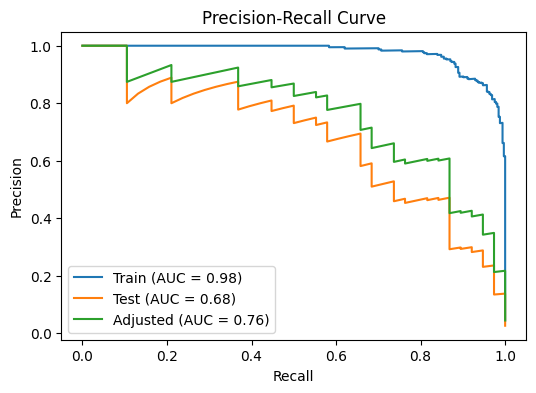

In [62]:
adjusted = adjust_pr_curve_from_roc(
    fpr=roc_auc_dict_test["fpr"],
    tpr=roc_auc_dict_test["tpr"],
    target_prevalence=y_train.value_counts(normalize=True)[True], # Train set prevalence
)
adjusted['name'] = "Adjusted"
pr_auc_dict_test['name'] = "Test"
pr_auc_dict_train['name'] = "Train"
plot_precision_recall_curve([pr_auc_dict_train, pr_auc_dict_test, adjusted])

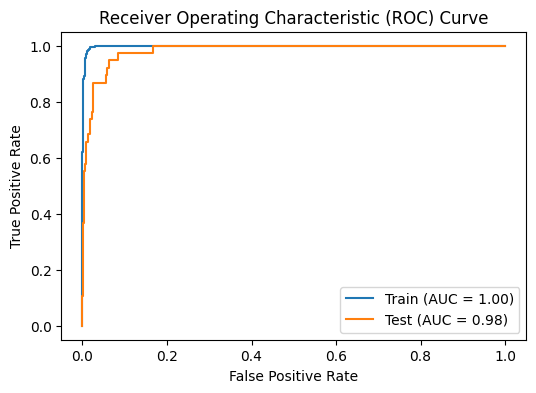

In [63]:
roc_auc_dict_train['name'] = "Train"
roc_auc_dict_test['name'] = "Test"
plot_roc_curve([roc_auc_dict_train, roc_auc_dict_test])